In [15]:
# защита от падения ядра IPython
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import f1_score, confusion_matrix
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [17]:
from src.train import train_resnet_model
from src.inference import inference_resnet_model

## Обучение нейросетей

In [18]:
class FFTDataset(Dataset):
    '''
    Dataset class for 1D-spectra and spectrograms
    '''
    def __init__(self, files, labels):
        '''
        Parameters:
        - files: list of *.npy files
        - labels: list of class labels
        '''
        self.data = []
        self.labels = []
        for filepath in files:
            self.data.append(torch.FloatTensor(np.load(filepath)).unsqueeze(0))
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index], self.labels[index]

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [20]:
from typing import List, Union, Dict
import random
from sklearn.model_selection import train_test_split


# для бинарной классификации обозначим "здоровый" сигнал как 0, сигналы с ошибками как 1
# и загрузим все ошибочные сигналы в датасет в равных долях 
def get_binary_dataloaders(healthy_folders_list: List[str],
                           fault_folders_list: List[str],
                           healthy_samples: Union[int, None] = None,
                           faulty_samples: Union[int, None] = None,
                           test_size: float = 0.25,
                           seed: int = 42,
                           batch_size = 32) -> List[DataLoader]:
    '''
    Function for creating dataloaders for binary classification

    Parameters:
    - healty_folder: folder containing "healty" signal *.npy files 
    - fault_folders_list: list of folders containing faulty signal *.npy files
    - healthy_samples: number of samples for "healthy" signal

    Returns:
    - list of dataloaders is in order: train, val, test
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    fft_list = []
    labels_list = []
    for signal_type in healthy_folders_list:
        healthy_list = list(Path(signal_type).rglob('*.npy'))
        if healthy_samples is not None:
            healthy_list = healthy_list[:healthy_samples]
        fft_list += healthy_list
        labels_list += [0 for _ in range(len(healthy_list))]
    for signal_type in fault_folders_list:
        fault_list = list(Path(signal_type).rglob('*.npy'))
        if faulty_samples is not None:
            fault_list = fault_list[:faulty_samples]
        fft_list += fault_list
        labels_list += [1 for _ in range(len(fault_list))]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset(Xtrain, ytrain)
    val_dataset = FFTDataset(Xval, yval)
    test_dataset = FFTDataset(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


# в мультиклассовой классификации каждый сигнал - отдельный класс
def get_multiclass_dataloaders(folders_list: List[str],
                               all_data_samples: Union[int, None] = None,
                               mapping: Union[Dict[int, int], None] = None,
                               test_size: float = 0.25,
                               seed: int = 42,
                               batch_size = 32) -> List[DataLoader]:
    '''
    Function for creating dataloaders for multiclass classification

    Parameters:
    - folders_list: list of folders containing *.npy files of different classes
    - all_data_samples: number of data samples for each class

    Returns:
    - list of dataloaders is in order: train, val, test
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    fft_list = []
    labels_list = []
    for i, signal_type in enumerate(folders_list):
        class_list = list(Path(signal_type).rglob('*.npy'))
        if all_data_samples is not None:
            class_list = class_list[:all_data_samples]
        fft_list += class_list
        labels_list += [i for _ in range(len(class_list))]
    if mapping is not None:
        for k, v in mapping.items():
            labels_list = [v if label == k else label for label in labels_list]
    Xtrain, Xtest, ytrain, ytest = train_test_split(fft_list, labels_list, random_state=seed, test_size=test_size)
    Xtrain, Xval, ytrain, yval = train_test_split(Xtrain, ytrain, random_state=seed, test_size=test_size)
    train_dataset = FFTDataset(Xtrain, ytrain)
    val_dataset = FFTDataset(Xval, yval)
    test_dataset = FFTDataset(Xtest, ytest)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

In [21]:
class ResidualBlock2d(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock2d, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = F.relu(self.bn1(out))
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample:
            residual = self.downsample(x)
        out += residual
        out = F.relu(out)
        return out


class ResNet2d(nn.Module):

    def __init__(self, block, layers, num_classes=2):
        super(ResNet2d, self).__init__()
        self.in_channels = 64
        self.conv = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3)
        self.bn = nn.BatchNorm2d(64)
        self.layer1 = self.make_layer(block, 64, layers[0])
        self.layer2 = self.make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self.make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self.make_layer(block, 512, layers[3], stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if (stride != 1) or (self.in_channels != out_channels):
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels))
        layers = []
        layers.append(
            block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = out.squeeze()
        out = self.fc(out)
        return out

Начнем с бинарной классификации.

In [23]:
healthy_fft = ['../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_spectrogram']
fault_fft = [
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_spectrogram',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_spectrogram'
    ]

train_loader, val_loader, test_loader = get_binary_dataloaders(healthy_fft, 
                                                               fault_fft,
                                                               healthy_samples=2000,
                                                               faulty_samples=2000//7)

In [ ]:
EPOCHS = 2
model_bin_2d = ResNet2d(ResidualBlock2d, [2, 2, 2, 2], num_classes=2).to(device)

train_resnet_model(model_bin_2d, train_loader, val_loader, device, EPOCHS)

Epoch 1/2:   0%|          | 0/66 [00:00<?, ?batch/s]

In [ ]:
target, pred = inference_resnet_model(model_bin_2d, test_loader, device)

Inference:   0%|          | 0/32 [00:00<?, ?batch/s]

In [ ]:
f1_score(target, pred)

0.996996996996997

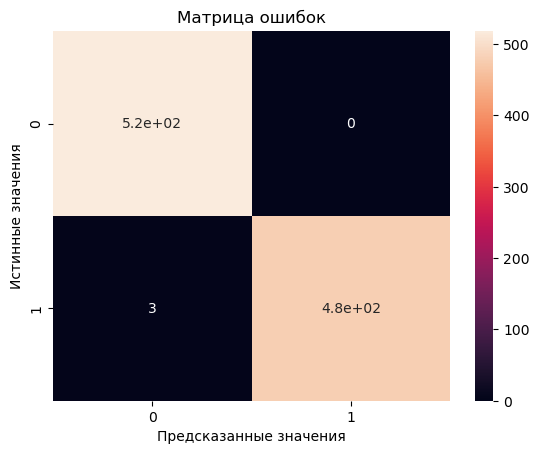

In [ ]:
sns.heatmap(confusion_matrix(target, pred), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()

Попробуем многоклассовую классификацию.

In [ ]:
signals_list = [
    '../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_spectrogram',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_spectrogram'
    ]

train_loader, val_loader, test_loader = get_multiclass_dataloaders(signals_list)

In [ ]:
x, y = next(iter(train_loader))

fig, ax = plt.subplots(nrows=2, ncols=2)
ax[0][0].imshow(x[0, :, :].squeeze())
ax[0][0].set_title(f'label = {y[0]}')
ax[1][0].imshow(x[1, :, :].squeeze())
ax[1][0].set_title(f'label = {y[1]}')
ax[0][1].imshow(x[2, :, :].squeeze())
ax[0][1].set_title(f'label = {y[2]}')
ax[1][1].imshow(x[3, :, :].squeeze())
ax[1][1].set_title(f'label = {y[3]}')
plt.show()

In [ ]:
EPOCHS = 2
resnet_mult_2d = ResNet2d(ResidualBlock2d, [2, 2, 2, 2], num_classes=8).to(device)

train_resnet_model(resnet_mult_2d, train_loader, val_loader, device, EPOCHS)

Epoch 1/5:   0%|          | 0/282 [00:00<?, ?batch/s]

Epoch [1/5], Loss: 0.2051
Validation Loss: 0.0010, Accuracy: 100.00%
[✓]   New best (multiclass) saved →  ..\res\checkpoints\resnet_best_multiclass.pth  (metric=1.0000)
  [✓] best model saved → ../res/checkpoints


Epoch 2/5:   0%|          | 0/282 [00:00<?, ?batch/s]

Epoch [2/5], Loss: 0.0322
Validation Loss: 0.0000, Accuracy: 100.00%


Epoch 3/5:   0%|          | 0/282 [00:00<?, ?batch/s]

...

Epoch 4/5:   0%|          | 0/282 [00:00<?, ?batch/s]

Epoch [4/5], Loss: 0.0012
Validation Loss: 0.0000, Accuracy: 100.00%


Epoch 5/5:   0%|          | 0/282 [00:00<?, ?batch/s]

Epoch [5/5], Loss: 0.0299
Validation Loss: 10.3887, Accuracy: 33.30%


ResNet(
  (conv): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (prior_attn): Identity()
  (layer1): Sequential(
    (0): ResidualBlock(
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (1): ResidualBlock(
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock(


In [ ]:
target, pred = inference_resnet_model(resnet_mult_2d, test_loader, device)

Inference:   0%|          | 0/125 [00:00<?, ?batch/s]

In [ ]:
f1_score(target, pred, average='micro')

1.0

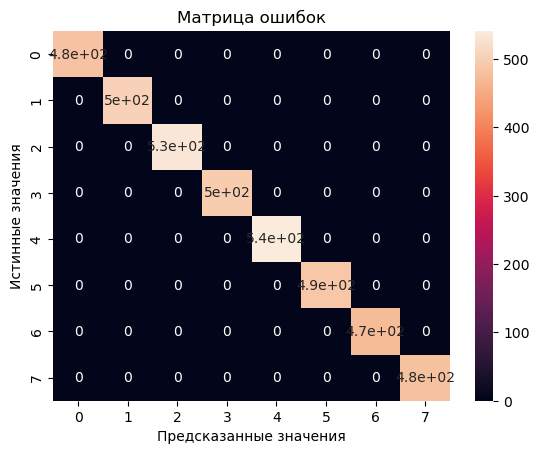

In [ ]:
sns.heatmap(confusion_matrix(target, pred), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()

Теперь поделим сигналы в точном соответствии с дефектами и еще раз обучим нейросеть:

In [ ]:
signals_list = [
    '../data/processed_engine_1/0702 без перекосов фаза A.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  перекос фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/0702  межвитковые фазы A ток фазы А.txt/ours_spectrogram',
    '../data/processed_engine_1/20_01_1460_об_мин_с_дисбалансом_ротора.txt/ours_spectrogram',
    '../data/processed_engine_1/21 02 дисбаланс макс обороты 100%.txt/ours_spectrogram',
    '../data/processed_engine_1/ВКЛ-ВЫКЛ нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/нагрузка 100% 11 01.txt/ours_spectrogram',
    '../data/processed_engine_1/холостой ход 11 01.txt/ours_spectrogram'
    ]

In [ ]:
mapping = {
    1: 0,
    2: 0,
    3: 1,
    4: 2,
    5: 3,
    6: 3,
    7: 3
}
train_loader, val_loader, test_loader = get_multiclass_dataloaders(signals_list, 
                                                                   all_data_samples=2000,
                                                                   mapping=mapping)

In [ ]:
EPOCHS = 2
resnet_mult_2d = ResNet2d(ResidualBlock2d, [2, 2, 2, 2], num_classes=4).to(device)

train_resnet_model(resnet_mult_2d, train_loader, val_loader, device, EPOCHS)

Epoch 1/5:   0%|          | 0/282 [00:00<?, ?batch/s]

Epoch [1/5], Loss: 0.0620
Validation Loss: 0.0000, Accuracy: 100.00%
[✓]   New best (multiclass) saved →  ..\res\checkpoints\resnet_best_multiclass.pth  (metric=1.0000)
  [✓] best model saved → ../res/checkpoints


Epoch 2/5:   0%|          | 0/282 [00:00<?, ?batch/s]

Epoch [2/5], Loss: 0.0205
Validation Loss: 0.0001, Accuracy: 100.00%


Epoch 3/5:   0%|          | 0/282 [00:00<?, ?batch/s]

...

Epoch 4/5:   0%|          | 0/282 [00:00<?, ?batch/s]

Epoch [4/5], Loss: 0.0029
Validation Loss: 0.0000, Accuracy: 100.00%


Epoch 5/5:   0%|          | 0/282 [00:00<?, ?batch/s]

Epoch [5/5], Loss: 0.0085
Validation Loss: 0.0331, Accuracy: 99.17%


ResNet(
  (conv): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (prior_attn): Identity()
  (layer1): Sequential(
    (0): ResidualBlock(
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (1): ResidualBlock(
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock(


In [ ]:
target, pred = inference_resnet_model(resnet_mult_2d, test_loader, device)

Inference:   0%|          | 0/125 [00:00<?, ?batch/s]

In [ ]:
f1_score(target, pred, average='micro')

1.0

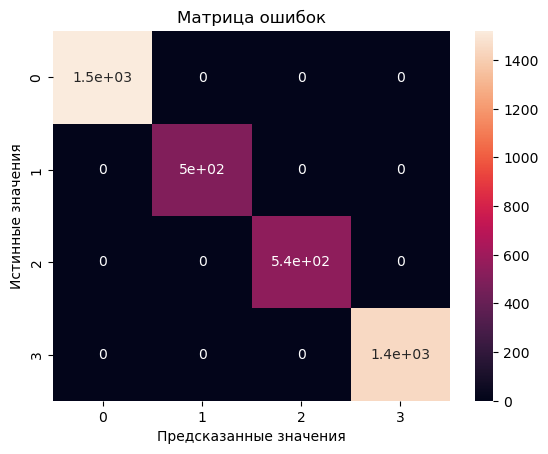

In [ ]:
sns.heatmap(confusion_matrix(target, pred), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()

Для engine_2:

In [ ]:
signals_list = [
    '../data/processed_engine_2/1st_load_60/1/1727785030/ours_spectrogram',
    '../data/processed_engine_2/2nd_load_60/1/1727789712/ours_spectrogram',
    '../data/processed_engine_2/3rd_load_60/1/1727863902/ours_spectrogram',
    '../data/processed_engine_2/4th_load_60/1/1727935897/ours_spectrogram'
    ]

train_loader, val_loader, test_loader = get_multiclass_dataloaders(signals_list)

In [ ]:
x, y = next(iter(train_loader))

fig, ax = plt.subplots(nrows=2, ncols=2)
ax[0][0].imshow(x[0, :, :].squeeze())
ax[0][0].set_title(f'label = {y[0]}')
ax[1][0].imshow(x[1, :, :].squeeze())
ax[1][0].set_title(f'label = {y[1]}')
ax[0][1].imshow(x[2, :, :].squeeze())
ax[0][1].set_title(f'label = {y[2]}')
ax[1][1].imshow(x[3, :, :].squeeze())
ax[1][1].set_title(f'label = {y[3]}')
plt.show()

In [ ]:
EPOCHS = 2
resnet_mult_2d = ResNet2d(ResidualBlock2d, [2, 2, 2, 2], num_classes=4).to(device)

train_resnet_model(resnet_mult_2d, train_loader, val_loader, device, EPOCHS)

Epoch 1/5:   0%|          | 0/44 [00:00<?, ?batch/s]

Epoch [1/5], Loss: 0.2762
Validation Loss: 1.0998, Accuracy: 65.15%
[✓]   New best (multiclass) saved →  ..\res\checkpoints\resnet_best_multiclass.pth  (metric=0.6515)
  [✓] best model saved → ../res/checkpoints


Epoch 2/5:   0%|          | 0/44 [00:00<?, ?batch/s]

Epoch [2/5], Loss: 0.0071
Validation Loss: 0.0000, Accuracy: 100.00%
[✓]   New best (multiclass) saved →  ..\res\checkpoints\resnet_best_multiclass.pth  (metric=1.0000)
  [✓] best model saved → ../res/checkpoints


Epoch 3/5:   0%|          | 0/44 [00:00<?, ?batch/s]

...

Epoch 4/5:   0%|          | 0/44 [00:00<?, ?batch/s]

Epoch [4/5], Loss: 0.0025
Validation Loss: 0.0003, Accuracy: 100.00%


Epoch 5/5:   0%|          | 0/44 [00:00<?, ?batch/s]

Epoch [5/5], Loss: 0.0005
Validation Loss: 0.0001, Accuracy: 100.00%


ResNet(
  (conv): Conv1d(1, 64, kernel_size=(7,), stride=(2,), padding=(3,))
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (prior_attn): Identity()
  (layer1): Sequential(
    (0): ResidualBlock(
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (1): ResidualBlock(
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock(


In [ ]:
target, pred = inference_resnet_model(resnet_mult_2d, test_loader, device)

Inference:   0%|          | 0/20 [00:00<?, ?batch/s]

In [ ]:
f1_score(target, pred, average='micro')

1.0

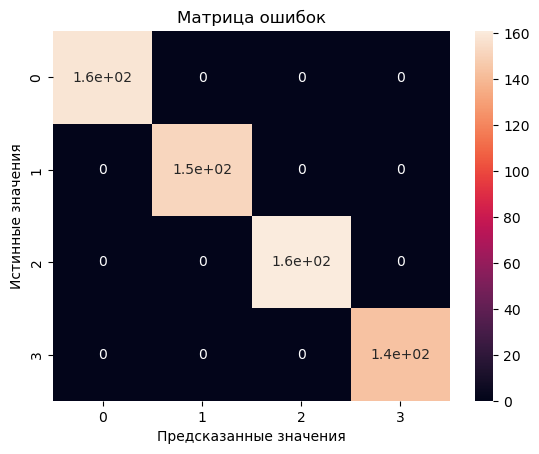

In [ ]:
sns.heatmap(confusion_matrix(target, pred), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()

Попробуем модель на других каналах:

In [ ]:
another_channels = []
for i in [2, 3]:
    signals_channel_list = [
        f'../data/processed_engine_2/1st_load_60/{i}/1727785030/ours_spectrogram',
        f'../data/processed_engine_2/2nd_load_60/{i}/1727789712/ours_spectrogram',
        f'../data/processed_engine_2/3rd_load_60/{i}/1727863902/ours_spectrogram',
        f'../data/processed_engine_2/4th_load_60/{i}/1727935897/ours_spectrogram'
        ]
    
    train, val, test = get_multiclass_dataloaders(signals_channel_list)
    target, pred = inference_resnet_model(resnet_mult_2d, test, device)
    another_channels.append((target, pred))

Inference:   0%|          | 0/20 [00:00<?, ?batch/s]

Inference:   0%|          | 0/20 [00:00<?, ?batch/s]

In [ ]:
f1_score(another_channels[0][0], another_channels[0][1], average='micro')

1.0

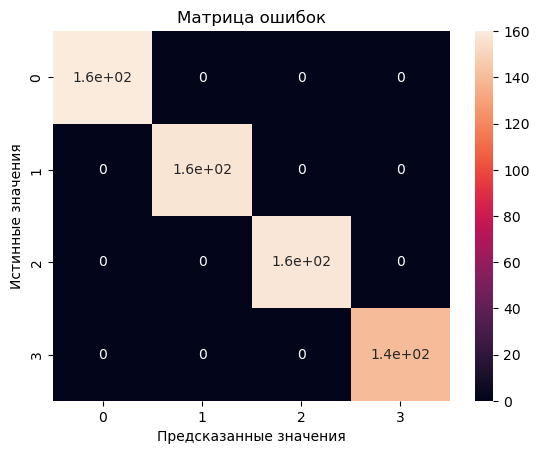

In [ ]:
sns.heatmap(confusion_matrix(another_channels[0][0], another_channels[0][1]), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()

In [ ]:
f1_score(another_channels[1][0], another_channels[1][1], average='micro')

1.0

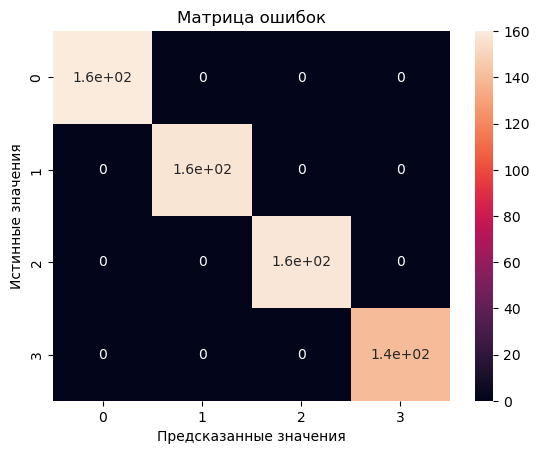

In [ ]:
sns.heatmap(confusion_matrix(another_channels[1][0], another_channels[1][1]), annot=True)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title('Матрица ошибок')
plt.show()